Import Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [5]:
df = pd.read_csv("Master_DS.csv")

df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Mortgage_Approvals,Net_Consumer_Credit,Net_Credit_Card_Lending
0,1995-01,1995,January,6.63,2.4,8.9,19.6,0.5,78866,399,162
1,1995-02,1995,February,6.63,2.4,8.9,19.6,0.5,80654,452,186
2,1995-03,1995,March,6.63,2.6,8.8,19.6,0.5,74872,535,158
3,1995-04,1995,April,6.63,2.3,8.8,19.8,0.2,75112,303,153
4,1995-05,1995,May,6.63,2.5,8.7,19.8,0.2,70629,276,182


Convert Date

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Mortgage_Approvals,Net_Consumer_Credit,Net_Credit_Card_Lending
0,1995-01-01,1995,January,6.63,2.4,8.9,19.6,0.5,78866,399,162
1,1995-02-01,1995,February,6.63,2.4,8.9,19.6,0.5,80654,452,186
2,1995-03-01,1995,March,6.63,2.6,8.8,19.6,0.5,74872,535,158
3,1995-04-01,1995,April,6.63,2.3,8.8,19.8,0.2,75112,303,153
4,1995-05-01,1995,May,6.63,2.5,8.7,19.8,0.2,70629,276,182


Dataset Overview

In [7]:
print(df.shape)

print()

df.info()

print()

df.describe()

(372, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     372 non-null    datetime64[ns]
 1   Year                     372 non-null    int64         
 2   Month                    372 non-null    object        
 3   Bank_Rate                372 non-null    float64       
 4   CPI                      372 non-null    float64       
 5   Unemployment_Rate        372 non-null    float64       
 6   House_Price_Index        372 non-null    float64       
 7   GDP_Growth               372 non-null    float64       
 8   Mortgage_Approvals       372 non-null    int64         
 9   Net_Consumer_Credit      372 non-null    int64         
 10  Net_Credit_Card_Lending  372 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(4), object(1)
memory usage: 32.1+ KB



,Date,Year,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Mortgage_Approvals,Net_Consumer_Credit,Net_Credit_Card_Lending
count,372,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000
mean,2010-06-16 14:03:52.258064640,2010.000000,3.089597,2.463978,5.702957,60.734140,0.496774,76992.577957,597.295699,341.236559
min,1995-01-01 00:00:00,1995.000000,0.100000,-0.100000,3.600000,19.600000,-19.900000,9369.000000,-2893.000000,-4946.000000
25%,2002-09-23 12:00:00,2002.000000,0.500000,1.400000,4.700000,42.425000,0.200000,61339.000000,393.750000,182.750000
50%,2010-06-16 00:00:00,2010.000000,4.000000,2.100000,5.200000,60.250000,0.600000,70284.000000,725.000000,353.500000
75%,2018-03-08 18:00:00,2018.000000,5.250000,2.900000,6.700000,79.725000,0.800000,96648.250000,937.000000,581.500000
max,2025-12-01 00:00:00,2025.000000,7.500000,11.100000,8.900000,104.300000,17.000000,132788.000000,1551.000000,1304.000000
std,NaN,8.956318,2.459424,1.916574,1.444524,24.590978,2.515835,24305.992379,546.443994,459.321917


Select Variables(Independent Variables)

In [8]:
X = df[
    [
        "Bank_Rate",
        "CPI",
        "Unemployment_Rate",
        "House_Price_Index",
        "GDP_Growth"
    ]
]

Dependent Variable

In [9]:
y = df["Mortgage_Approvals"]

Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(297, 5)
(75, 5)


Train Linear Regression Model

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


Model Coefficients

In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Bank_Rate,2076.411483
1,CPI,-1997.046391
2,Unemployment_Rate,-8966.570507
3,House_Price_Index,-608.018465
4,GDP_Growth,2543.575262


Intercept

In [13]:
print("Intercept:", model.intercept_)

Intercept: 161930.99833314208


Make Predictions

In [14]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 55130.13999401, 103444.66711821,  83452.43463624,  60728.79055838,
       105005.68173789,  72375.53864518, 104888.32767023,  95181.29792656,
        20465.6229594 ,  93237.24664843])

Model Evaluation

In [15]:
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("R² Score :", r2)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

R² Score : 0.5813094714587187
MAE : 11182.853712718148
MSE : 224535082.1255139
RMSE : 14984.494723730724


Actual vs Predicted

In [16]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
327,66065,55130.139994
33,82722,103444.667118
15,79685,83452.434636
314,81078,60728.790558
57,101108,105005.681738
239,60159,72375.538645
76,107529,104888.327670
119,83449,95181.297927
305,40299,20465.622959
126,98670,93237.246648


Scatter Plot (Actual vs Predicted)

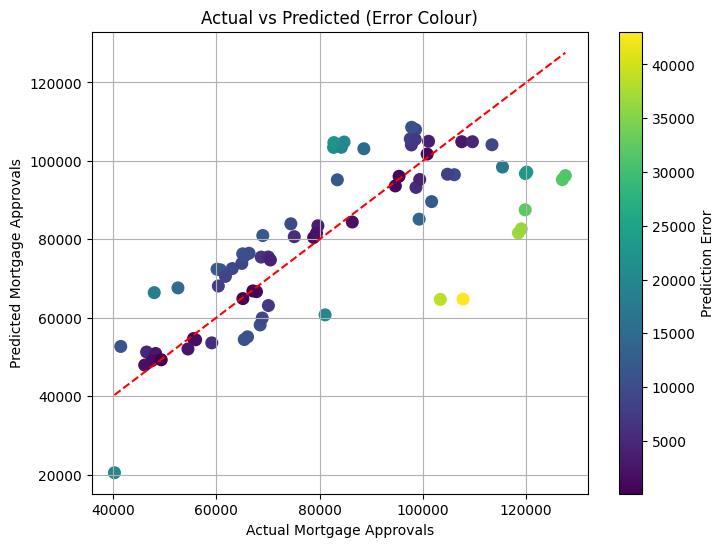

In [21]:
errors = abs(y_test - y_pred)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    y_test,
    y_pred,
    c=errors,
    cmap="viridis",
    s=70
)

plt.colorbar(scatter,label="Prediction Error")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Mortgage Approvals")
plt.ylabel("Predicted Mortgage Approvals")
plt.title("Actual vs Predicted (Error Colour)")
plt.grid(True)

plt.show()

In [18]:
import statsmodels.api as sm

X = df[[
    "Bank_Rate",
    "CPI",
    "Unemployment_Rate",
    "House_Price_Index",
    "GDP_Growth"
]]

X = sm.add_constant(X)

y = df["Mortgage_Approvals"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Mortgage_Approvals   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     109.4
Date:                Fri, 17 Jul 2026   Prob (F-statistic):           1.99e-70
Time:                        07:51:40   Log-Likelihood:                -4114.0
No. Observations:                 372   AIC:                             8240.
Df Residuals:                     366   BIC:                             8263.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.64e+05   8144.74

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[[
    "Bank_Rate",
    "CPI",
    "Unemployment_Rate",
    "House_Price_Index",
    "GDP_Growth"
]]

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

            Variable       VIF
0          Bank_Rate  2.553957
1                CPI  3.382599
2  Unemployment_Rate  5.599197
3  House_Price_Index  5.195536
4         GDP_Growth  1.043054


**Model 2: Household Deposit Volume**

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
X = df[['Bank_Rate',
        'CPI',
        'Unemployment_Rate',
        'House_Price_Index',
        'GDP_Growth']]

In [27]:
y = df['Net_Consumer_Credit']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred = model2.predict(X_test)

In [31]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R² Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

R² Score : 0.4307664354724461
MAE : 268.03219541066244
MSE : 116168.2947073131
RMSE : 340.8347029093621


In [32]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model2.coef_
})

print(coefficients)

print("\nIntercept :", model2.intercept_)

             Feature  Coefficient
0          Bank_Rate    46.174482
1                CPI   -13.217641
2  Unemployment_Rate  -236.670793
3  House_Price_Index    -6.417653
4         GDP_Growth    72.988122

Intercept : 2187.617843186651


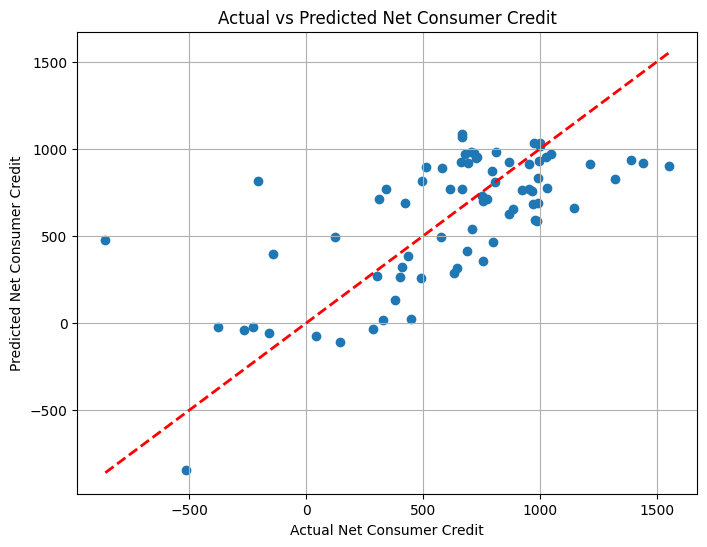

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--',
         linewidth=2)

plt.xlabel("Actual Net Consumer Credit")
plt.ylabel("Predicted Net Consumer Credit")
plt.title("Actual vs Predicted Net Consumer Credit")

plt.grid(True)

plt.show()

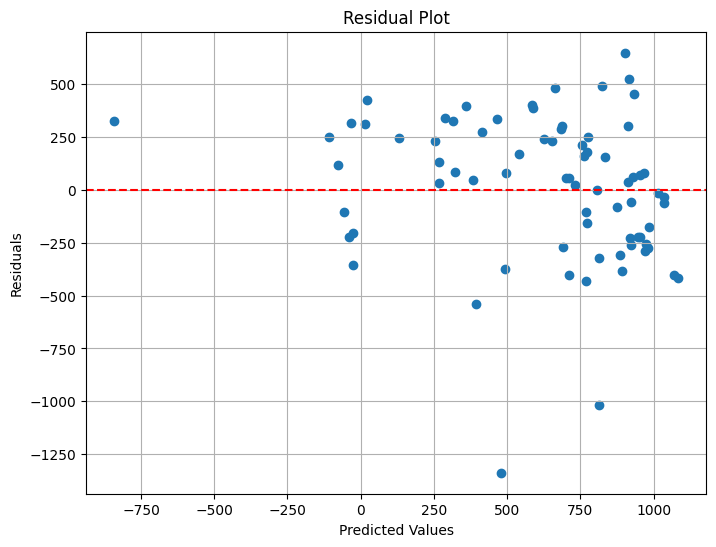

In [34]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.show()